In [30]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
data = load_diabetes(as_frame=True)

X = data.data
y = data.target

X.head()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [ ]:
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
}

In [ ]:
results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model),
    ])

    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)

    results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": mean_squared_error(y_test, preds) ** 0.5,
        "R2": r2_score(y_test, preds),
    })

result_df = pd.DataFrame(results)
result_df.sort_values("MAE")

In [ ]:
cv_results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model),
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="neg_mean_absolute_error",
    )

    mae_scores = -scores

    cv_results.append({
        "model": name,
        "cv_mae_mean": mae_scores.mean(),
        "cv_mae_std": mae_scores.std(),
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df.sort_values("cv_mae_mean")

In [ ]:
ridge_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0)),
])

lasso_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.1, max_iter=10000)),
])

ridge_pipeline.fit(X_train, y_train)
lasso_pipeline.fit(X_train, y_train)

In [ ]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "ridge_coef": ridge_pipeline.named_steps["model"].coef_,
    "lasso_coef": lasso_pipeline.named_steps["model"].coef_
})

coef_df

In [ ]:
coef_df.set_index("feature")[["ridge_coef", "lasso_coef"]].plot(kind="bar", figsize=(12, 5))

plt.title("Ridge vs Lasso coefficients")
plt.ylabel("Coefficient value")
plt.show()

In [31]:
# Task A
data = load_diabetes(as_frame=True)

X = data.data
y = data.target

X.head()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
)

In [32]:
# Task B
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.1, max_iter=10000),
}

In [33]:
# Task C
results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model),
    ])

    pipeline.fit(X_train, y_train)
    preds = pipeline.predict(X_test)
    results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": mean_squared_error(y_test, preds) ** 0.5,
        "R2": r2_score(y_test, preds),
    })

result_df = pd.DataFrame(results)
result_df.sort_values("MAE")

,model,MAE,RMSE,R2
0,LinearRegression,42.794095,53.853446,0.452603
2,Lasso,42.805234,53.708698,0.455541
1,Ridge,42.811999,53.777454,0.454147


In [34]:
# Task D
cv_results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model),
    ])

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=5,
        scoring="neg_mean_absolute_error",
    )

    mae_scores = -scores

    cv_results.append({
        "model": name,
        "cv_mae_mean": mae_scores.mean(),
        "cv_mae_std": mae_scores.std(),
    })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df.sort_values("cv_mae_mean")

,model,cv_mae_mean,cv_mae_std
2,Lasso,44.255609,2.014306
1,Ridge,44.264654,2.031338
0,LinearRegression,44.276499,2.100110


In [44]:
# Task E
ridge_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0)),
])

lasso_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", Lasso(alpha=0.1, max_iter=1000)),
])

ridge_pipeline.fit(X_train, y_train)
lasso_pipeline.fit(X_train, y_train)

coef_df = pd.DataFrame({
    "feature": X.columns,
    "ridge_coef": ridge_pipeline.named_steps["model"].coef_,
    "lasso_coef": lasso_pipeline.named_steps["model"].coef_
})
coef_df

,feature,ridge_coef,lasso_coef
0,age,1.807342,1.730451
1,sex,-11.448190,-11.316359
2,bmi,25.732699,25.824627
3,bp,16.734300,16.644252
4,s1,-34.671954,-29.358412
5,s2,17.053075,13.275844
6,s3,3.369914,0.547948
7,s4,11.764260,10.236168
8,s5,31.378384,29.632826
9,s6,2.458139,2.393475


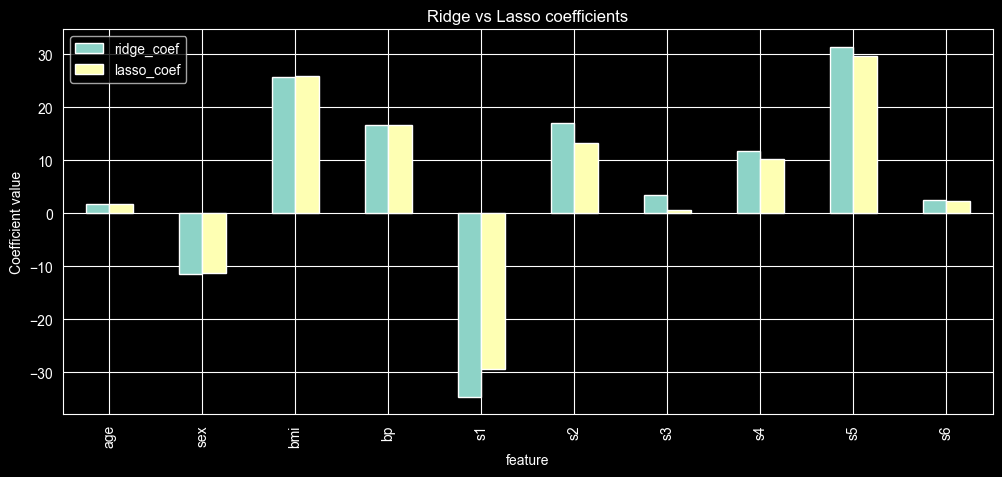

In [45]:
# Task F
coef_df.set_index("feature")[["ridge_coef", "lasso_coef"]].plot(kind="bar", figsize=(12, 5))

plt.title("Ridge vs Lasso coefficients")
plt.ylabel("Coefficient value")
plt.show()

## Выводы

- Регуляризация помогает ограничить сложность линейной модели.
- Ridge использует L2-регуляризацию и уменьшает коэффициенты.
- Lasso использует L1-регуляризацию и может занулять некоторые коэффициенты.
- Alpha управляет силой регуляризации.
- StandardScaler важен, потому что признаки должны быть в сопоставимом масштабе.
- Cross-validation лучше подходит для сравнения моделей, а test можно оставить для финальной проверки.